In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/slt-examples


In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn_ext.mixture import BinomialMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
from plot import visualize_joint_confidence_regions
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [3]:
total_experiments = 3
n_trials=100 # number of dna sites checked
dgp_filepath = "./binomix/meta.csv"
dgp_raw = {
    "id"  : [str(i) for i in range(total_experiments)],
    "n" : np.ones(total_experiments).astype(int)*n_trials,
    "rho1" : np.array([0.7, 0.7, 1]), # probability of selecting a person with MSI1 tumor
    "p1" : np.array([0.3, 0.3, 0.3]), # probability of per site mutation if MSI1 tumor
    "p2" : np.array([0.2, 0.3, 0.2]), # probability of per site mutation if MSI2 tumor
}
dgp_raw["rho2"] = 1-dgp_raw["rho1"]
pd.DataFrame(dgp_raw).set_index("id").to_csv(dgp_filepath)

In [4]:
dgp=pd.read_csv(dgp_filepath, index_col=0)
dgp.head()

,n,rho1,p1,p2,rho2
id,,,,,
0,100,0.7,0.3,0.2,0.3
1,100,0.7,0.3,0.3,0.3
2,100,1.0,0.3,0.2,0.0


In [5]:
obs_pathstr = "./binomix/ds{dsid}-n{n}.csv"
datasets_count = dgp.shape[0]
n_steps = [100, 500, 1000] # number of patients in the study
n_replications = 1000 # number of replications of each dataset size
for dsid in range(datasets_count):
    for _, n in enumerate(n_steps):
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        if file.exists(): # check if this data has already been generated
            print(f"File {file} exists, dsid={dsid}, n={n} random sample creation skipped!")
        else:
            if file.parent: # create parents dir if not already
                file.parent.mkdir(parents=True, exist_ok=True)

            n_trials = dgp.loc[dsid, ["n"]].astype(int).item()
            weights = dgp.loc[dsid, ["rho1", "rho2"]].tolist()
            probs = dgp.loc[dsid, ["p1", "p2"]].tolist()
            dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
            X = {}
            X["n_trials"] = np.ones(n, dtype=int)*n_trials
            for k in range(1, n_replications+1): # generate 1 file per data set
                samples = dd.sample(n_samples=n)
                X[f"x_{k}"] = samples[0].astype(int).tolist()
            
            obs = pd.DataFrame(X)
            obs.to_csv(file)
            print(f"Created {file} with {n_trials} for dataset id {dsid} and {n} random samples")

Created binomix/ds0-n100.csv with 100 for dataset id 0 and 100 random samples
Created binomix/ds0-n500.csv with 100 for dataset id 0 and 500 random samples
Created binomix/ds0-n1000.csv with 100 for dataset id 0 and 1000 random samples
Created binomix/ds1-n100.csv with 100 for dataset id 1 and 100 random samples
Created binomix/ds1-n500.csv with 100 for dataset id 1 and 500 random samples
Created binomix/ds1-n1000.csv with 100 for dataset id 1 and 1000 random samples
Created binomix/ds2-n100.csv with 100 for dataset id 2 and 100 random samples
Created binomix/ds2-n500.csv with 100 for dataset id 2 and 500 random samples
Created binomix/ds2-n1000.csv with 100 for dataset id 2 and 1000 random samples


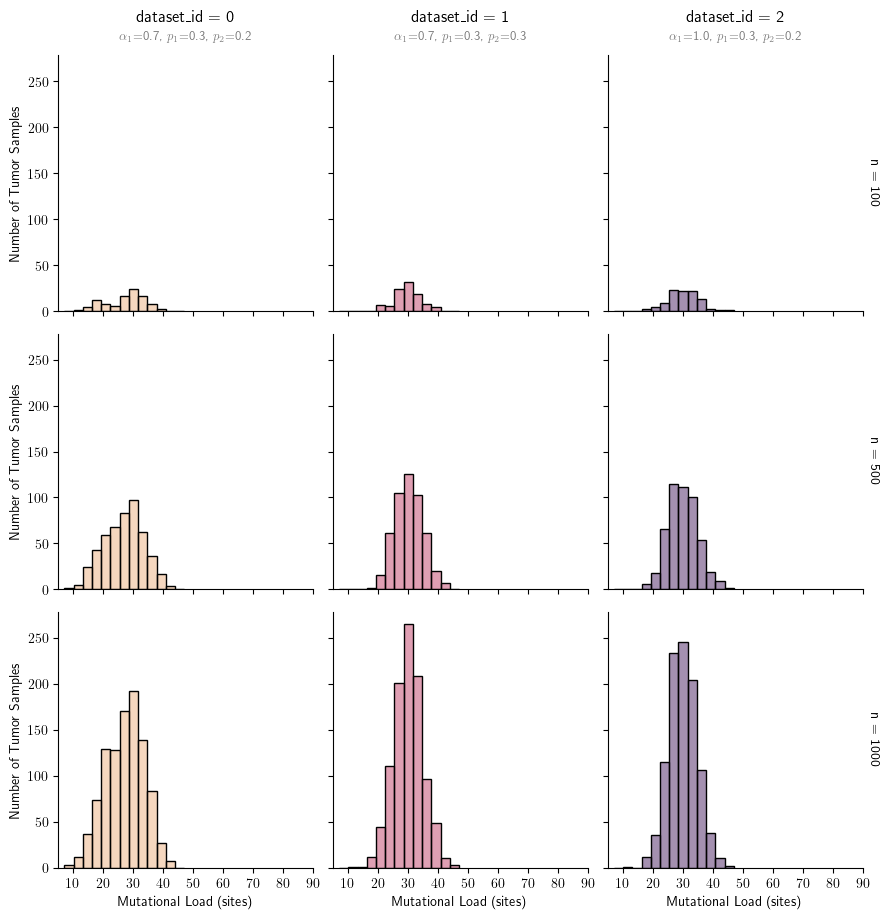

In [38]:
trial_index = 2 #which replication to use from each dataset
plotdata = {"x": [], "n": [], "dataset_id": []} # raw data to initialize the plotting dataframe

for dsid in range(datasets_count):
    for n in n_steps:
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        Xs = pd.read_csv(file)
        # print(Xs.head())
        ss = len(Xs.iloc[:,trial_index])
        x=Xs.iloc[:,trial_index].tolist()
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["n"]=np.append(plotdata["n"], (np.ones(ss)*n).astype(int))
        plotdata["dataset_id"]=np.append(plotdata["dataset_id"], np.ones(ss).astype(int)*dsid)


plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "n": int, "dataset_id": int})
g=sns.displot(
    plotdf, x="x", col="dataset_id", row="n", bins=n_trials, hue="dataset_id",
    binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": True}, legend=False, palette="flare"
)
g.set_axis_labels("Mutational Load (sites)", "Number of Tumor Samples")

subtitles={}
for i in range(datasets_count):
    ditem = dgp.iloc[i,:]
    subtitles[str(i)]=f'$\\alpha_1$={ditem["rho1"].item()}, $p_1$={ditem["p1"].item()}, $p_2$={ditem["p2"].item()}'

# Only modify the top row of subplots (these have the column titles)
for ax in g.axes[0, :]:  # [0, :] means first row, all columns
    title = ax.get_title()
    if ' = ' in title:
        col_value = title.split(' = ')[1]
        if col_value in subtitles:
            # ax.set_title(f'{column_labels[col_value]}')
            # Set the main title
            ax.set_title(title, pad=25)
            
            # Add subtitle as text annotation
            ax.text(0.5, 1.05, subtitles[col_value], 
                   transform=ax.transAxes, 
                   ha='center', va='bottom',
                   fontsize=9, style='italic', color='gray')

for ax in g.axes.flat:
    ax.set_xticks(list(range(10, n_trials,10)))
plt.savefig('binomix/dataset.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
def compute_mle(x_obs, max_iter=10**6, tol=10e-4):
    # Fit main GMM
    bmm = BinomialMixture(n_components=2,
                          max_iter=max_iter, 
                          tol=tol,
                          n_init=10)

    bmm.fit(x_obs)
    bmm._enforce_ordering() 

    mle = {
        "p1": bmm.probs_[0],
        "p2": bmm.probs_[1], 
        "rho1": bmm.weights_[0],
        "rho2": bmm.weights_[1]
    }
    return mle

mle={"trial_index": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "dsid": []}
for dsid in range(datasets_count):
    n=1000
    # for n in tqdm(n_steps, desc=f"n_steps"):
    file = Path(obs_pathstr.format(dsid=dsid, n=n))
    Xs = pd.read_csv(file)
    for k in tqdm(range(1, n_replications+1), desc=f"mle fit for dataset {dsid} ands n={n}"):
        kdata = Xs[[f"x_{k}", "n_trials", ]]
        estimate=compute_mle(x_obs=kdata)
        assert estimate["p1"] >= estimate["p2"], f"p1={estimate["p1"]} < p2={estimate["p2"]}"
        mle["trial_index"].append(k)
        mle["rho1"].append(estimate["rho1"])
        mle["rho2"].append(estimate["rho2"])
        mle["p1"].append(estimate["p1"])
        mle["p2"].append(estimate["p2"])
        mle["dsid"].append(dsid)

mle_df = pd.DataFrame(mle)
mle_df.head()

mle fit for dataset 0 ands n=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 1 ands n=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 2 ands n=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

,trial_index,rho1,rho2,p1,p2,dsid
0,1,0.726462,0.273538,0.297544,0.200211,0
1,2,0.696875,0.303125,0.303004,0.200162,0
2,3,0.706871,0.293129,0.297074,0.200857,0
3,4,0.628272,0.371728,0.305532,0.208600,0
4,5,0.683191,0.316809,0.300400,0.204663,0


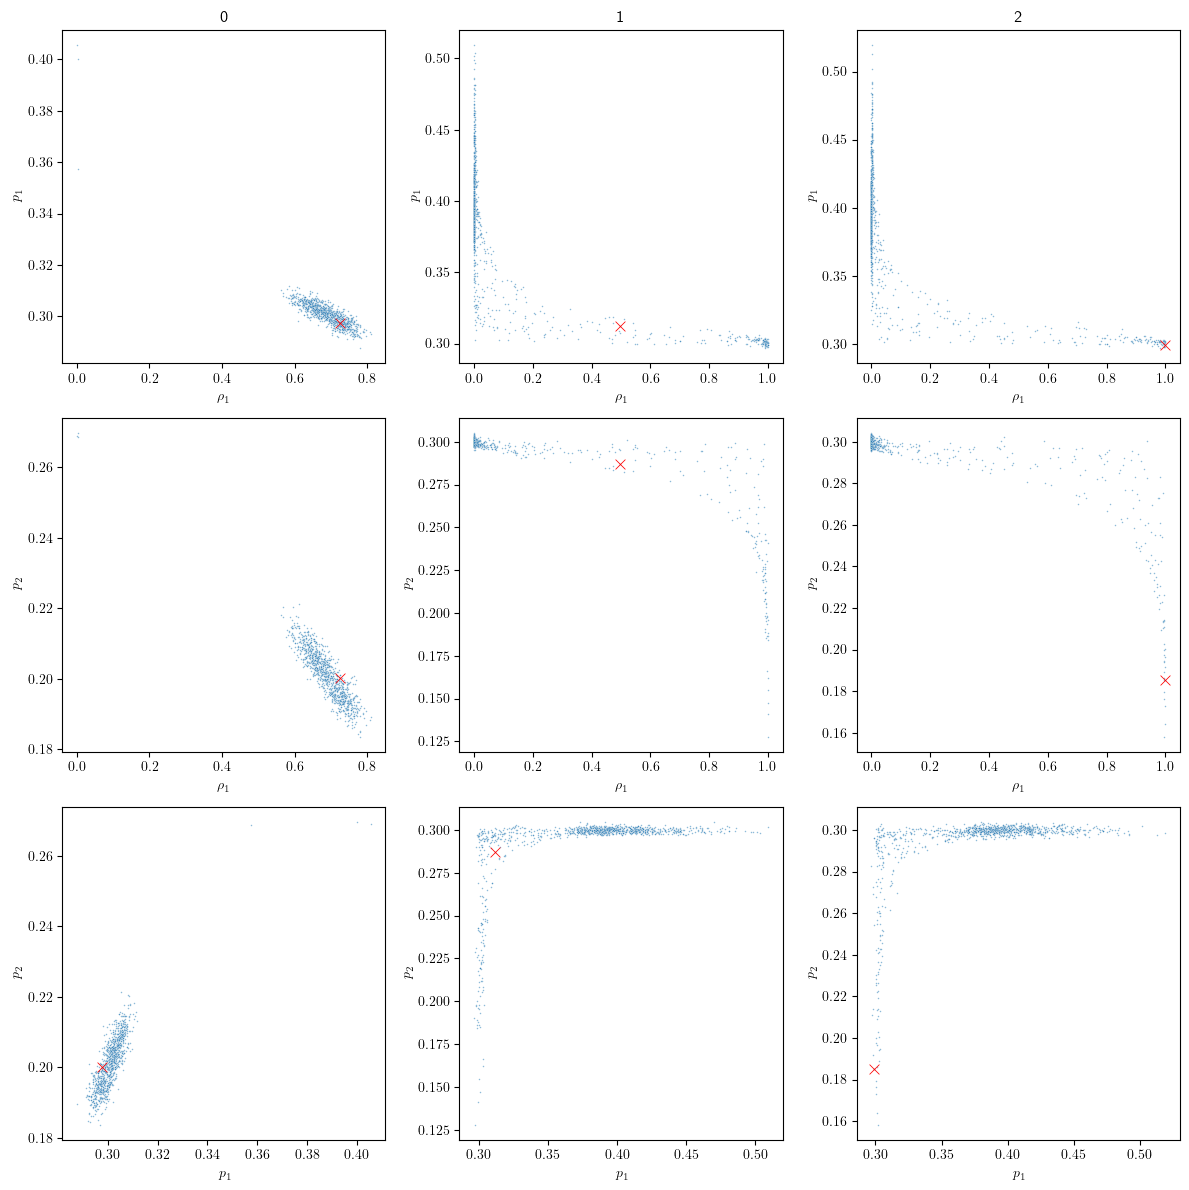

In [37]:
import seaborn as sns

fig, axes = plt.subplots(
    3, len(mle_df['dsid'].unique()), 
    figsize=(4*len(mle_df['dsid'].unique()), 12),
    sharex=False,
    sharey=False
)

pairs = [('rho1', 'p1'), ('rho1', 'p2'), ('p1', 'p2')]
pair_labels = [('$\\rho_1$', '$p_1$'), ('$\\rho_1$', '$p_2$'), ('$p_1$', '$p_2$')]
dsids = sorted(mle_df['dsid'].unique())

for i, ((x_var, y_var), (x_label, y_label)) in enumerate(zip(pairs, pair_labels)):
    for j, dsid in enumerate(dsids):
        data_subset = mle_df[mle_df['dsid'] == dsid]
        
        # Use seaborn scatterplot instead of matplotlib scatter
        sns.scatterplot(data=data_subset, x=x_var, y=y_var, 
                       alpha=0.5, s=5, marker='.', ax=axes[i, j])
        
        # Find and overlay trial_index=1 point
        trial_1_point = data_subset[data_subset['trial_index'] == 1]
        if not trial_1_point.empty:
            sns.scatterplot(data=trial_1_point, x=x_var, y=y_var, 
                           color='red', marker='x', s=50, alpha=1.0, ax=axes[i, j])
        
        axes[i, j].set_xlabel(x_label)
        axes[i, j].set_ylabel(y_label)
        
        if i == 0:
            axes[i, j].set_title(f'{dsid}')

plt.tight_layout()
plt.savefig('binomix/mle_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

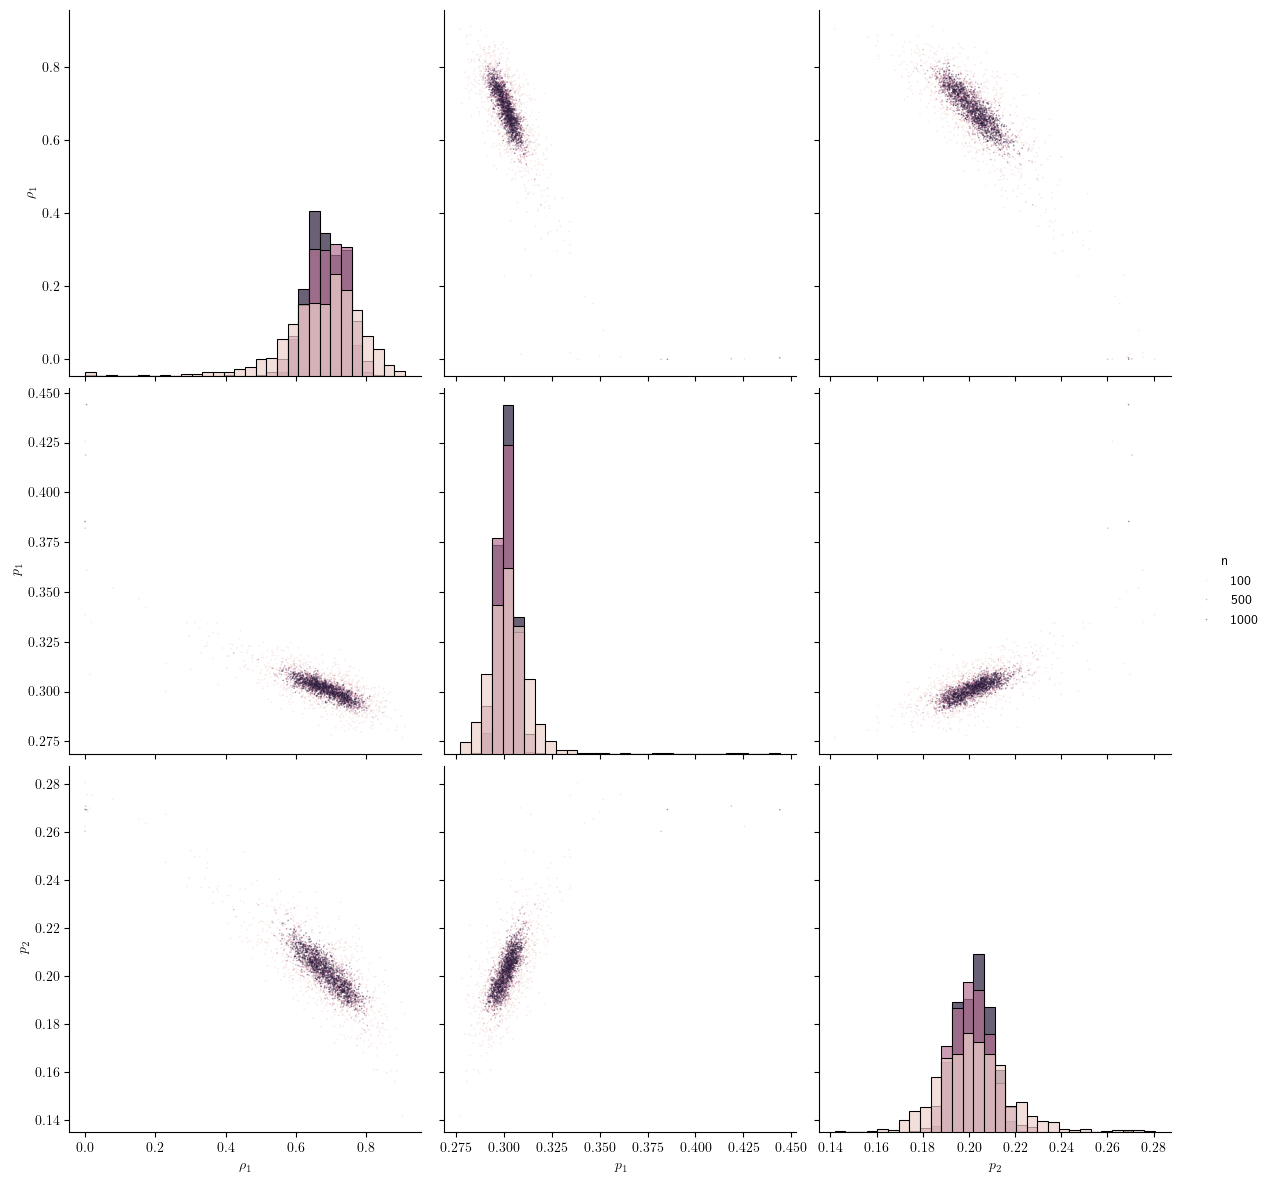

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$', 
        'p1': '$p_1$', 
        'p2': '$p_2$'
    }), 
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2, 
                                   tol=tol, 
                                   max_iter=max_iter,
                                   n_init=n_init)
        
        bmm_boot.fit(X_boot)
        
        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering() 
    
        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1], 
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None


def bootstrapit(X, max_iter=10**6, tol=10e-4, n_bootstrap=10000, parallelism_n_jobs=-1):
    # compute_mle(x_obs, max_iter=10**6, tol=10e-4):
    # Bootstrap
    # Parallel execution with progress bar
    results = Parallel(n_jobs=parallelism_n_jobs, verbose=0)(
        delayed(resample_and_fit)(X, i, len(x_obs), max_iter, tol) 
        for i in range(n_bootstrap)
    )

    # Filter out None results (non-converged)
    converged_results = [r for r in results if r is not None]

    # print(f"Converged bootstrap samples: {len(converged_results)}/{n_bootstrap}")
    # print(f"Successful bootstrap samples: {len(p1_boot)}/{n_bootstrap}")
    
    if len(converged_results) < 50:  # Too few successful samples
        print("Warning: Very few successful bootstrap samples!")
        return {"error": "Bootstrap failed - too few successful samples"}
    
    estimates = {"ss": len(x_obs)}

    for pname in ["p1", "p2", "rho1", "rho2"]:
        estimates[pname] = {
            "mle": mle[pname],
            "bootstraps": [r[pname] for r in converged_results],
            "ci_lower": np.percentile([r[pname] for r in converged_results], 2.5),
            "ci_upper": np.percentile([r[pname] for r in converged_results], 97.5),
        }
    
    return estimates

In [32]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]
            
            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

experiment :   0%|          | 0/4 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Bootstrap confidence regions, n=250')

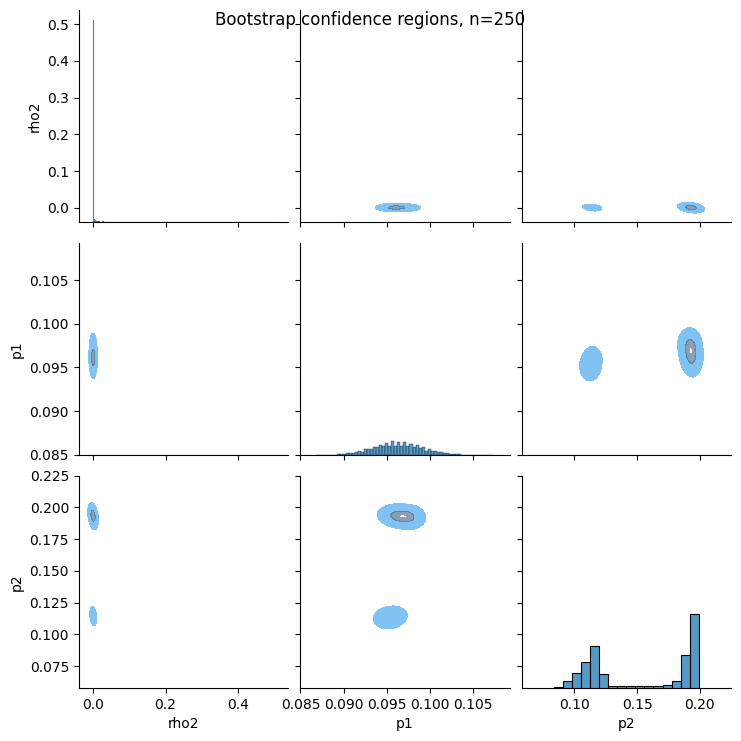

In [37]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"], 
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata, 
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods
    
# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995], 
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')
    
    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [31]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min
            
        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max
        
        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper
        
        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)
        
        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")